In [18]:
import torch

import xarray as xr
import numpy as np
import pandas as pd

from constants import *
from neural_net import get_net

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

In [19]:
torch.manual_seed(10)

# Settings

In [20]:
device = torch.device("cuda:0")
dtype = torch.bfloat16

In [21]:
batch_size = 8

# 15 day forecast length
n_forecast_length = 16

lead_time_axis = pd.Timedelta("6h") * np.arange(1, n_forecast_length+1)

# Load data

In [22]:
ds_test = xr.open_zarr("../data/sqg_test.zarr")["q"].compute()

# Estimate score for persistence

In [23]:
initial_conditions = ds_test[:-n_forecast_length]
n_times_total = len(initial_conditions)
print(n_times_total)
print(n_forecast_length)

10
16


In [24]:
persistence_mse = [] # mse when state[t+1]=state[t] for every t 
# persistance is the baseline 

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]

    # Loop over lead times
    batch_mse = []
    for ld in range(1, n_forecast_length+1):
        # Get prediction
        curr_prediction = curr_initial.values # persistance forecast
        # for every lead time = 6hrs --> same conditions 

        # Error estimation --> comparing persistence forecast at time t with actual ERA5 data for that time  
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        # get error and average over spatial dimensions to get MSE per time sample (starting time) and lead time (delta t) 
        mse = ((error**2) * weights_lat.numpy()).mean(["longitude", "latitude"]) 
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    persistence_mse.append(batch_mse)
# concatenate all computed MSE values 
persistence_mse = xr.concat(persistence_mse, dim="time")

  0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
persistence_mse.shape # (forecast length, time, variables) 
# time = total time steps - forecast length for horizon

(16, 10, 1)

(16, 1)


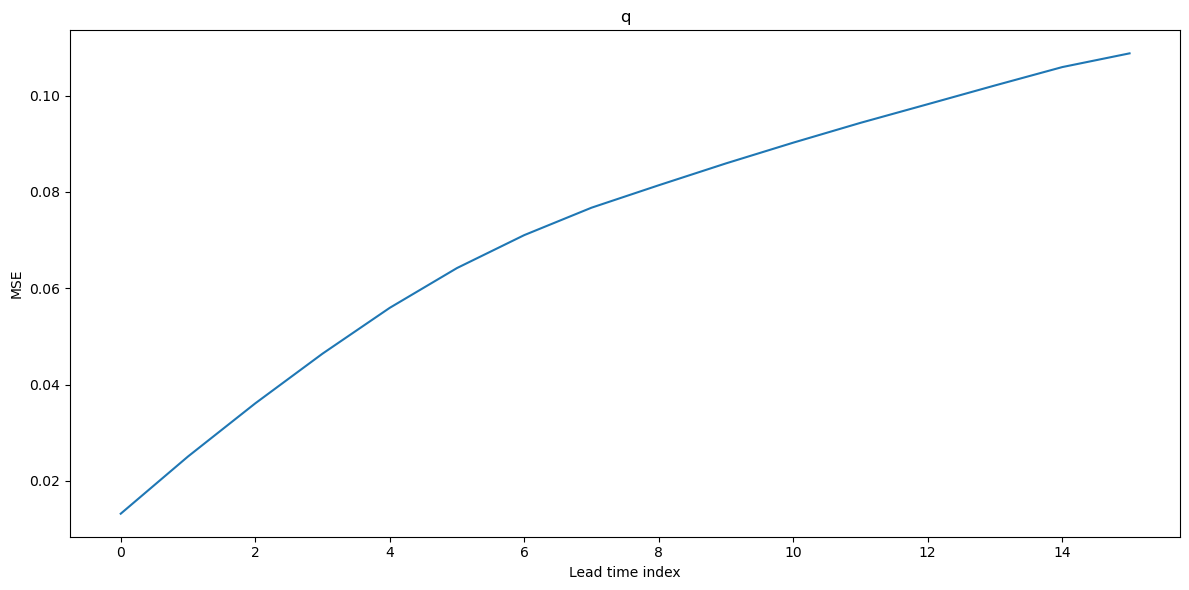

In [26]:
mse_by_lead_time = persistence_mse.mean(dim="time")
print(mse_by_lead_time.shape)

plt.figure(figsize=(12,6))

plt.plot(mse_by_lead_time[:, 0])
plt.title(f"q")
plt.ylabel("MSE")

plt.xlabel("Lead time index")
plt.tight_layout()
plt.show()

# Loop neural network to get NN forecast

## Load neural network

In [27]:
# perhaps you forgot which hyperparameters the trained net had... 
sd = torch.load("../data/best_model_test.ckpt", map_location="cpu")
for k,v in sd.items():
    print(k, tuple(v.shape))

tokenizer.in_layer.weight (64, 2, 2, 2)
blocks.0.attn_norm.weight (64,)
blocks.0.ffn_norm.weight (64,)
blocks.0.attn.qkv_layer.weight (192, 64)
blocks.0.attn.q_norm.weight (8,)
blocks.0.attn.k_norm.weight (8,)
blocks.0.attn.out_layer.weight (64, 64)
blocks.0.ffn.in_layer.weight (256, 64)
blocks.0.ffn.out_layer.weight (64, 128)
blocks.1.attn_norm.weight (64,)
blocks.1.ffn_norm.weight (64,)
blocks.1.attn.qkv_layer.weight (192, 64)
blocks.1.attn.q_norm.weight (8,)
blocks.1.attn.k_norm.weight (8,)
blocks.1.attn.out_layer.weight (64, 64)
blocks.1.ffn.in_layer.weight (256, 64)
blocks.1.ffn.out_layer.weight (64, 128)
blocks.2.attn_norm.weight (64,)
blocks.2.ffn_norm.weight (64,)
blocks.2.attn.qkv_layer.weight (192, 64)
blocks.2.attn.q_norm.weight (8,)
blocks.2.attn.k_norm.weight (8,)
blocks.2.attn.out_layer.weight (64, 64)
blocks.2.ffn.in_layer.weight (256, 64)
blocks.2.ffn.out_layer.weight (64, 128)
blocks.3.attn_norm.weight (64,)
blocks.3.ffn_norm.weight (64,)
blocks.3.attn.qkv_layer.weight

In [28]:
# this needs to have the same params as the trained net 
net = get_net(
n_input=1,
n_output=1,
n_blocks=8,
n_features=64,
token_downsample_factor=1,
device=device,
dtype=dtype,
)
state_dict = torch.load("../data/best_model_test.ckpt", map_location="cpu")
net.load_state_dict(state_dict)
net = net.eval().to(device=device, dtype=dtype)

In [29]:
nn_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Loop over lead times
    batch_mse = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # Get prediction
        net_io = torch.from_numpy(curr_prediction)
        net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
        with torch.no_grad():
            net_io = net(net_io).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = ((error**2) * weights_lat.numpy()).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    nn_mse.append(batch_mse)
nn_mse = xr.concat(nn_mse, dim="time")

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

In [30]:
print(nn_mse.shape) # same shape as the persistance mse 

(16, 10, 1)


(16, 1)


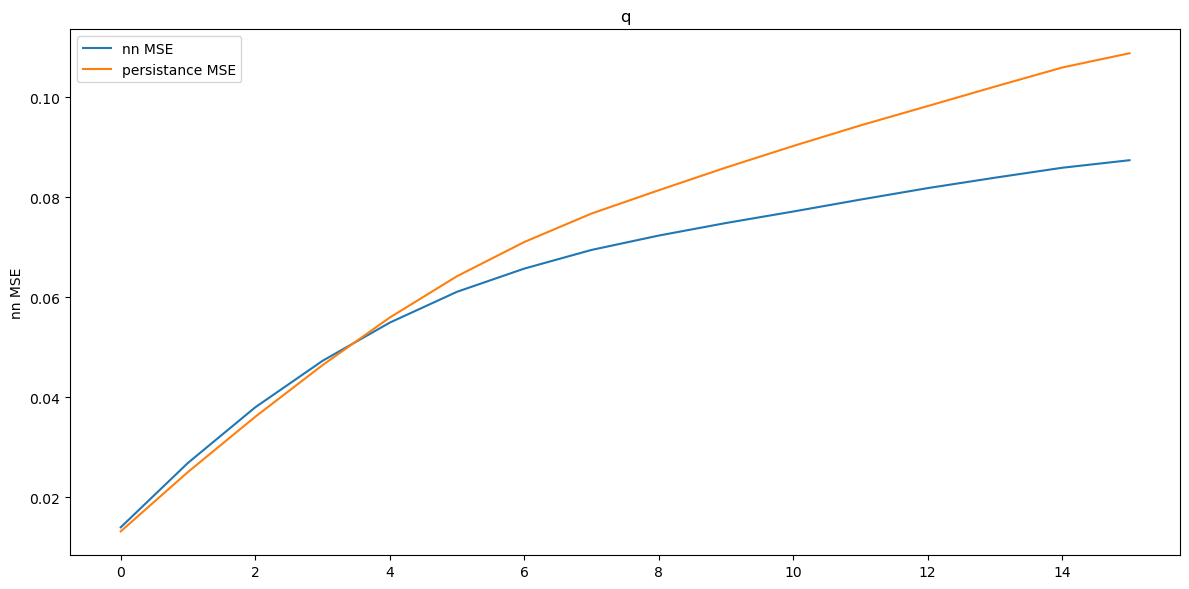

In [33]:
nn_mse_by_lead_time = nn_mse.mean(dim="time")
print(nn_mse_by_lead_time.shape)

plt.figure(figsize=(12, 6)) 

plt.plot(nn_mse_by_lead_time[:], label="nn MSE")
plt.plot(mse_by_lead_time[:], label="persistance MSE")
plt.title("q")
plt.ylabel("nn MSE")
plt.legend()

axes[-1].set_xlabel("Lead time index")
plt.tight_layout()
plt.show()

Clearly different fields have different natural variability, therefore the MSE varies too over very different scales. To have comparable values we normalize by input standard deviation --> rMSE

# Plot scores and predictions

# nRMSE

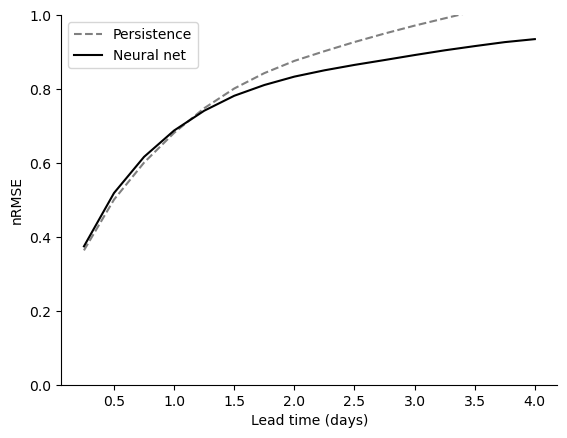

In [34]:
fig, ax = plt.subplots(dpi=100)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    # average over the variables and over time --> one single synthesis plot 
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((persistence_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])), 
    label="Persistence", c="0.5", ls="--")
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((nn_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Neural net", c="black", ls="-"
)

ax.set_ylabel("nRMSE")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 1.)

ax.legend()

## GH 500 hPa

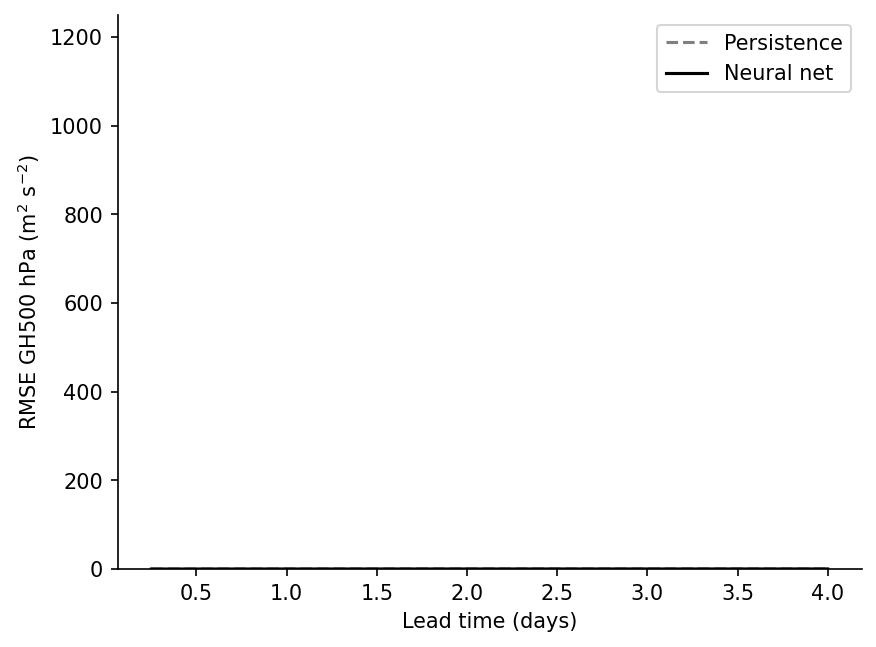

In [35]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position("zero")
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(persistence_mse.mean("time")[:, 0]),
    label="Persistence", c="0.5", ls="--"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt(nn_mse.mean("time")[:, 0]),
    label="Neural net", c="black", ls="-"
)

ax.set_ylabel("RMSE GH500 hPa (m$^2$ s$^{-2}$)")
ax.set_xlabel("Lead time (days)") 
ax.set_ylim(0, 1250.)

ax.legend()

# Plot prediction

In [47]:
start_time = 225
end_time = 235

In [54]:
sliced_truth = ds_test.sel(time=slice(start_time, end_time))
print(sliced_truth.shape) 

current = sliced_truth.values[0][None]   # (1,1,512,512)
predictions = [current]

# convert to avoid type mismatch 
res_std  = res_std.cpu().numpy()
res_mean = res_mean.cpu().numpy()
in_mean  = in_mean.cpu().numpy()
in_std   = in_std.cpu().numpy()

for _ in tqdm(range(len(sliced_truth) - 1)):

    net_io = torch.from_numpy(current)
    net_io = ((net_io - in_mean) / in_std).to(device=device, dtype=dtype)

    with torch.no_grad():
        net_out = net(net_io).cpu().float().numpy()

    current = current + (net_out * res_std + res_mean)   # still (1,1,512,512)
    predictions.append(current)

prediction = np.concatenate(predictions, axis=0)  # (T,1,512,512)
prediction = sliced_truth.copy(data=prediction)

(11, 1, 512, 512)


  0%|          | 0/10 [00:00<?, ?it/s]

In [61]:
def plot_q(ax, q, qmax=None):
    q2d = q.squeeze()
    n = q2d.shape[0]
    x = np.linspace(0, 2*np.pi, n)
    y = np.linspace(0, 2*np.pi, n)
    pc = ax.pcolormesh(x, y, q2d, cmap="seismic", shading="auto")
    if qmax is None:
        qmax = np.abs(q2d).max()
    pc.set_clim(-qmax, qmax)
    ax.set_aspect("equal")
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)

    return pc

In [64]:
def plot_predictions_grid(prediction, step=1):
    """
    Plot prediction fields in rows of 3.
    step = skip frames to avoid 100 tiny plots.
    """
    fields = prediction[::step]
    n = len(fields)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))

    # Flatten axes for easy looping
    axes = np.atleast_1d(axes).ravel()

    # global symmetric color scale
    qmax = np.abs(fields).max()

    for i, (ax, q) in enumerate(zip(axes, fields)):
        pc = plot_q(ax, q, qmax=qmax)
        ax.set_title(f"t = {i*step}")

    # Hide unused panels
    for ax in axes[n:]:
        ax.axis("off")

    # One shared colorbar
    fig.colorbar(pc, ax=axes[:n], shrink=0.8)

    plt.show()

(11, 1, 512, 512)


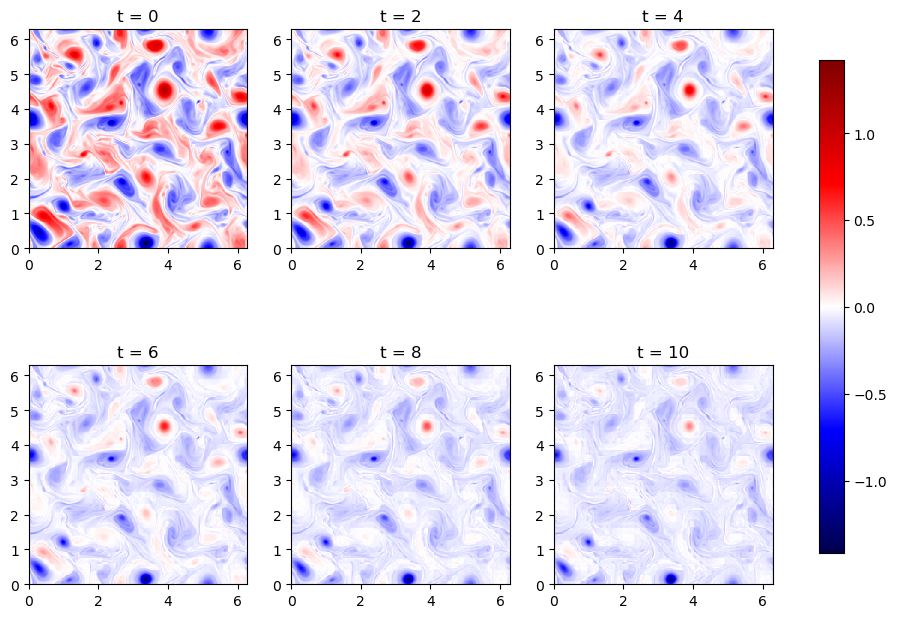

In [65]:
print(prediction.shape)
plot_predictions_grid(prediction, step=2)